In [ ]:
import pandas as pd

CSV_FILE_NAME = "retell_calls_mindflow.csv"

# 1. FIX DE NOTAÇÃO CIENTÍFICA:
# Forçamos o Pandas a ler o telefone e IDs como TEXTO puro (String) para não perder nenhum dígito.
tipos = {
    'to_number': str,
    'from_number': str,
    'call_id': str
}

df_original = pd.read_csv(CSV_FILE_NAME, dtype=tipos, low_memory=False)

# 2. FIX DA DUPLICAÇÃO FANTASMA:
# Vamos garantir que não existam logs duplicados para a mesma ligação.
tamanho_antes = len(df_original)

# Ordenamos por data e mantemos apenas o primeiro log de cada call_id
df_original = df_original.sort_values('created_at').drop_duplicates(subset=['call_id'], keep='first')

tamanho_depois = len(df_original)
print(f"Ingestão concluída. Linhas originais: {tamanho_antes} | Após remover duplicatas (logs fantasmas): {tamanho_depois}")
print(f"Total de duplicatas removidas: {tamanho_antes - tamanho_depois}")

Fetching data...
Fetched 1000 rows...
Fetched 2000 rows...
Fetched 3000 rows...
Fetched 4000 rows...
Fetched 5000 rows...
Fetched 6000 rows...
Fetched 7000 rows...
Fetched 8000 rows...
Fetched 9000 rows...
Fetched 10000 rows...
Fetched 11000 rows...
Fetched 12000 rows...
Fetched 13000 rows...
Fetched 14000 rows...
Fetched 15000 rows...
Fetched 16000 rows...
Fetched 17000 rows...
Fetched 18000 rows...
Fetched 19000 rows...
Fetched 20000 rows...
Fetched 21000 rows...
Fetched 22000 rows...
Fetched 23000 rows...
Fetched 24000 rows...
Fetched 25000 rows...
Fetched 26000 rows...
Fetched 27000 rows...
Fetched 28000 rows...
Fetched 29000 rows...
Fetched 30000 rows...
Fetched 31000 rows...
Fetched 32000 rows...
Fetched 33000 rows...
Fetched 34000 rows...
Fetched 35000 rows...
Fetched 36000 rows...
Fetched 37000 rows...
Fetched 38000 rows...
Fetched 39000 rows...
Fetched 40000 rows...
Fetched 41000 rows...
Fetched 42000 rows...
Fetched 43000 rows...
Fetched 44000 rows...
Fetched 45000 rows...
Fe

,id,created_at,Nome,Email,data,Numero,status,call_id,call_type,agent_id,...,LLM_cost,combined_cost,call_summary,LLM_token_usage,from_number,to_number,Duracao,Marcada,segmento,equipe
0,73818,2026-03-27T20:52:06.466776+00:00,CRISTIANO CURVELLO GRIMALDI.,cristiano.grimaldi@gmail.com.,27/03/2026 16,+5521981009872,ended,call_77d1c1361ceee67eb81eb6a84ff,phone_call,agent_1e4cfa23e3910c557d82167949,...,3.15,14.3,None,4.5,iatizeia,+5521981009872,41406,None,None,None
1,73822,2026-03-27T20:52:20.285419+00:00,EMERSON.....,emersonwan@gmail.com....,27/03/2026 16,+5541999934270,not_connected,call_224fce976e0f56b738d37b1f96e,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+5541999934270,0,None,None,None
2,73823,2026-03-27T20:52:28.397644+00:00,GABRIEL SEIXAS TEIXEIRA...,mimiseixas@gmail.com,27/03/2026 16,+5571981714102,not_connected,call_12009b93ac3604a4360ca8d2bcf,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+5571981714102,0,None,None,None
3,73827,2026-03-27T20:52:30.281646+00:00,MIKAEL.....,mikael.fontes@hotmail.com....,27/03/2026 16,+551198557771,not_connected,call_b4b3727b1876f2f223714cfd135,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+551198557771,0,None,None,None
4,73834,2026-03-27T20:52:48.692329+00:00,WILSON RIBEIRO PEIXOTO.,swempreendimento@gmail.com,27/03/2026 16,+5585991894805,not_connected,call_6e92b5988c017e6da55c9a1f656,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+5585991894805,0,None,None,None


In [ ]:
df=df_original.copy()

In [ ]:
len(df_original)

145553

In [ ]:
# Exibir as 5 últimas linhas do DataFrame
display(df.tail(5))

,id,created_at,Nome,Email,data,Numero,status,call_id,call_type,agent_id,...,LLM_cost,combined_cost,call_summary,LLM_token_usage,from_number,to_number,Duracao,Marcada,segmento,equipe
145548,40938,2026-03-14T18:36:12.06858+00:00,JOSE..,None,14/03/2026 14,+5511994796402,not_connected,call_05273531ccc11ab84e3afa28eeb,phone_call,agent_2117bcaaf68e8b7cc8e0d160f7,...,None,0,None,None,iatizeia,+5511994796402,0,None,None,None
145549,40941,2026-03-14T18:36:19.947708+00:00,NICOLAS..,None,14/03/2026 14,+5551997861611,ended,call_b534aa8ded852e3a5d4cfafad41,phone_call,agent_2117bcaaf68e8b7cc8e0d160f7,...,0.3,0.7666667,None,None,iatizeia,+5551997861611,3099,None,None,None
145550,40944,2026-03-14T18:36:27.730148+00:00,Anderson Carlos Dias Silva,None,14/03/2026 14,+5521994950696,ended,call_c78625fbaab0978b907ae56c3d3,phone_call,agent_2117bcaaf68e8b7cc8e0d160f7,...,1.275,3.4583333,None,0.2,iatizeia,+5521994950696,16664,false,None,None
145551,40945,2026-03-14T18:36:47.679762+00:00,LUIZ....,None,14/03/2026 14,+5511984606290,not_connected,call_9e530b2a81aff1f36cea98ca2a6,phone_call,agent_2117bcaaf68e8b7cc8e0d160f7,...,None,0,None,None,iatizeia,+5511984606290,0,None,None,None
145552,40947,2026-03-14T18:37:09.718341+00:00,LUIZ....,None,14/03/2026 14,+5511939530583,not_connected,call_ff19e7456b21b3caa58cbfc699a,phone_call,agent_2117bcaaf68e8b7cc8e0d160f7,...,None,0,None,None,iatizeia,+5511939530583,0,None,None,None


In [ ]:
df.columns

Index(['id', 'created_at', 'Nome', 'Email', 'data', 'Numero', 'status',
       'call_id', 'call_type', 'agent_id', 'agent_version', 'agent_name',
       'transcript', 'recording_url', 'disconnection_reason',
       'eleven_labs_cost', 'LLM', 'LLM_cost', 'combined_cost', 'call_summary',
       'LLM_token_usage', 'from_number', 'to_number', 'Duracao', 'Marcada',
       'segmento', 'equipe'],
      dtype='object')

In [ ]:
df["agent_name"].unique()

array(['Agente Mindflow Disparo', 'Agente Mindflow (Formulário) ',
       'Agente Mindflow (whatsapp)',
       'Agente Mindflow Reagendamento/confirmação',
       'Agente Mindflow (Imobiliárias) ',
       'Agente Mindflow (Infoprodutores)', None], dtype=object)

In [ ]:
df=df[df['agent_name']=='Agente Mindflow Disparo']

In [ ]:
# Remover as colunas especificadas
columns_to_drop = ['Nome','Email','data','Numero','transcript','recording_url','eleven_labs_cost','LLM','LLM_cost','Marcada', 'segmento', 'equipe', 'from_number', 'agent_version', 'call_summary']
df = df.drop(columns=columns_to_drop)

# Verificar o novo estado do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109567 entries, 0 to 145502
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    109567 non-null  int64 
 1   created_at            109567 non-null  object
 2   status                109567 non-null  object
 3   call_id               109555 non-null  object
 4   call_type             109567 non-null  object
 5   agent_id              109567 non-null  object
 6   agent_name            109567 non-null  object
 7   disconnection_reason  95023 non-null   object
 8   combined_cost         109567 non-null  object
 9   LLM_token_usage       26471 non-null   object
 10  to_number             109567 non-null  object
 11  Duracao               95023 non-null   object
dtypes: int64(1), object(11)
memory usage: 10.9+ MB


In [ ]:
# Converter colunas para numérico
df['combined_cost'] = pd.to_numeric(df['combined_cost'], errors='coerce')
df['Duracao'] = pd.to_numeric(df['Duracao'], errors='coerce')

# Converter id para string
df['id'] = df['id'].astype(str)

# Converter created_at para datetime e ajustar para o fuso de Brasília
df['created_at'] = pd.to_datetime(df['created_at'])
df['created_at_br'] = df['created_at'].dt.tz_convert('America/Sao_Paulo')

In [ ]:
# Converter Duracao de milissegundos para segundos
df['Duracao'] = df['Duracao'] / 1000

In [ ]:
# Filtrar chamadas com duração entre 10 e 45 segundos
df_intermediarias = df[(df['Duracao'] >= 10) & (df['Duracao'] <= 45)]

# Exibir informações básicas do recorte
print(f"Total de chamadas entre 10s e 45s: {len(df_intermediarias)}")
display(df_intermediarias.head())

Total de chamadas entre 10s e 45s: 21733


,id,created_at,status,call_id,call_type,agent_id,agent_name,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br
0,73818,2026-03-27 20:52:06.466776+00:00,ended,call_77d1c1361ceee67eb81eb6a84ff,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,14.300000,4.5,+5521981009872,41.406,2026-03-27 17:52:06.466776-03:00
11,73874,2026-03-27 20:54:16.637533+00:00,ended,call_5ec646e366811a92cc884e2ced7,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,3.766667,1.2000000000000002,+5561998699932,10.939,2026-03-27 17:54:16.637533-03:00
16,73819,2026-03-27 20:52:11.987339+00:00,ended,call_0fd801112041d0c6b51ded6170c,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,14.633333,4.6000000000000005,+5541992269872,42.249,2026-03-27 17:52:11.987339-03:00
25,73868,2026-03-27 20:54:06.401890+00:00,ended,call_0548f6ddaf067723b47ad115ec1,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,10.533333,3.3000000000000003,+552798118311,30.294,2026-03-27 17:54:06.401890-03:00
26,73872,2026-03-27 20:54:16.626802+00:00,ended,call_289aeb4fd88745319e6b78d839c,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,13.866667,4.3,+5547991210219,40.946,2026-03-27 17:54:16.626802-03:00


In [ ]:
df.describe()

,combined_cost,Duracao
count,109567.000000,95023.000000
mean,3.269932,11.280425
std,7.804291,24.426779
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.566667,11.554000
max,294.600000,782.416000


In [ ]:
# Filtrar onde Duracao não é nulo e não é 0
df_filtered = df[df['Duracao'].notna() & (df['Duracao'] != 0)]

# Exibir as primeiras 5 linhas do resultado
display(df_filtered.head())

,id,created_at,status,call_id,call_type,agent_id,agent_name,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br
0,73818,2026-03-27 20:52:06.466776+00:00,ended,call_77d1c1361ceee67eb81eb6a84ff,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,14.300000,4.5,+5521981009872,41.406,2026-03-27 17:52:06.466776-03:00
11,73874,2026-03-27 20:54:16.637533+00:00,ended,call_5ec646e366811a92cc884e2ced7,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,3.766667,1.2000000000000002,+5561998699932,10.939,2026-03-27 17:54:16.637533-03:00
12,73877,2026-03-27 20:54:18.594874+00:00,ended,call_f164596f1de85442c57ec8c54ee,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,voicemail_reached,0.933333,None,+5551993273900,3.168,2026-03-27 17:54:18.594874-03:00
16,73819,2026-03-27 20:52:11.987339+00:00,ended,call_0fd801112041d0c6b51ded6170c,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,14.633333,4.6000000000000005,+5541992269872,42.249,2026-03-27 17:52:11.987339-03:00
19,73843,2026-03-27 20:53:14.508665+00:00,ended,call_f1a410fe4b0ecc594cc1a743330,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,1.400000,None,+5561999596921,5.770,2026-03-27 17:53:14.508665-03:00


In [ ]:
df[df['call_id']=='call_dbb15bc20acbe52a13f6887d4ee']

,id,created_at,status,call_id,call_type,agent_id,agent_name,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br


In [ ]:
# Remover call_id duplicados mantendo o último registro
df = df.sort_values('created_at').drop_duplicates(subset=['call_id'], keep='last')

# Verificar o novo tamanho do DataFrame
print(f'Novo total de registros: {len(df)}')
display(df.head())

Novo total de registros: 28847


,id,created_at,status,call_id,call_type,agent_id,agent_name,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br
128321,38689,2026-03-13 21:19:27.285082+00:00,ongoing,call_dfb604820c4fd2c9973c750b63d,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,None,0.000000,None,+5521993749043,NaN,2026-03-13 18:19:27.285082-03:00
64188,38696,2026-03-13 21:21:17.840798+00:00,ongoing,call_663bbae36f82c9ffdf0cf86a716,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,None,0.000000,None,+5511971802008,NaN,2026-03-13 18:21:17.840798-03:00
43001,38865,2026-03-13 22:02:27.588568+00:00,ended,call_5148d4da9d968dee154cbdf5299,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,3.683333,1,+5521988255430,13.666,2026-03-13 19:02:27.588568-03:00
43002,38869,2026-03-13 22:03:30.349460+00:00,ended,call_b193619f182530efef3cd7a3ee4,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,10.566667,2.9000000000000004,+5521984230392,39.574,2026-03-13 19:03:30.349460-03:00
43003,38871,2026-03-13 22:03:54.894386+00:00,ended,call_247a54dede25db67c0d538b0e7d,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,10.858333,3,+5521981894944,40.326,2026-03-13 19:03:54.894386-03:00


In [ ]:
import pandas as pd
from datetime import datetime, timedelta

# Configurações de conversão
TAXA_CAMBIO = 5.30  # Cotação estimada do Dólar para Real

# Somar o custo total de toda a base processada (convertendo de centavos de dólar para Reais)
# 1. soma / 100 = Valor em USD
# 2. Valor em USD * TAXA_CAMBIO = Valor em BRL
custo_total_centavos = df['combined_cost'].sum()
custo_reais = (custo_total_centavos / 100) * TAXA_CAMBIO

print(f"Custo total histórico acumulado no DataFrame:")
print(f"Em centavos de USD: {custo_total_centavos:,.2f}")
print(f"Convertido para Reais (câmbio R$ {TAXA_CAMBIO:.2f}): R$ {custo_reais:,.2f}")

Custo total histórico acumulado no DataFrame:
Em centavos de USD: 107,359.54
Convertido para Reais (câmbio R$ 5.30): R$ 5,690.06


In [ ]:
df.describe()

,combined_cost,Duracao
count,28847.000000,28572.000000
mean,3.721688,11.221992
std,8.148063,24.001553
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,3.766667,11.415500
max,294.600000,782.416000


### Resumo do Processamento de Dados

Até o momento, realizamos as seguintes etapas no conjunto de dados `Retell_calls_Mindflow`:

1.  **Conexão e Extração:** Conectamos ao Supabase e extraímos 61.411 registros em chunks para evitar timeouts.
2.  **Filtragem de Agente:** Filtramos o DataFrame para manter apenas as chamadas do `Agente Mindflow Disparo`.
3.  **Limpeza de Colunas:** Removemos colunas irrelevantes ou redundantes para a análise (como `transcript`, `recording_url`, `LLM_cost`, etc.).
4.  **Conversão de Tipos:**
    *   Convertemos `combined_cost` e `Duracao` para formato numérico.
    *   Convertemos `id` para string.
    *   Convertemos `created_at` para datetime e ajustamos para o fuso horário de **Brasília (America/Sao_Paulo)**.
5.  **Tratamento da Duração:** Convertemos a coluna `Duracao` de milissegundos para **segundos**.
6.  **Remoção de Duplicados:** Ordenamos os dados cronologicamente e removemos registros duplicados de `call_id`, mantendo apenas a última atualização de cada chamada.
7.  **Resultado Final:** O DataFrame foi reduzido de ~61k para **10.614 registros únicos** e limpos.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estatísticas descritivas detalhadas da duração (em segundos)
duracao_stats = df['Duracao'].describe(percentiles=[.25, .5, .75, .90, .95, .99])
print("Estatísticas da Duração (Segundos):")
display(duracao_stats)

Estatísticas da Duração (Segundos):


,Duracao
count,28572.000000
mean,11.221992
std,24.001553
min,0.000000
25%,0.000000
50%,0.000000
75%,11.415500
90%,41.120900
95%,43.238600
99%,69.203870


In [ ]:
# 1. Porcentagem de ligações com duração não nula e não zero
total_ligacoes = len(df)
ligacoes_com_duracao = df[(df['Duracao'].notna()) & (df['Duracao'] > 0)]

porcentagem_ativa = (len(ligacoes_com_duracao) / total_ligacoes) * 100

# 2. Ligações com duração > 60 segundos (dentro do grupo acima)
ligacoes_longas = ligacoes_com_duracao[ligacoes_com_duracao['Duracao'] > 60]

# 3. Porcentagem de longas sobre as ativas
porcentagem_longas_sobre_ativas = (len(ligacoes_longas) / len(ligacoes_com_duracao)) * 100

print(f"Total de ligações únicas: {total_ligacoes}")
print(f"Ligações com duração > 0s (Ativas): {len(ligacoes_com_duracao)} ({porcentagem_ativa:.2f}% do total)")
print(f"Ligações com duração > 60s: {len(ligacoes_longas)}")
print(f"Porcentagem de > 60s sobre as ativas: {porcentagem_longas_sobre_ativas:.2f}%")

Total de ligações únicas: 28847
Ligações com duração > 0s (Ativas): 10962 (38.00% do total)
Ligações com duração > 60s: 391
Porcentagem de > 60s sobre as ativas: 3.57%


## Dado/Fato
Identificamos um problema. Poucas ligações passando de 1 minuto.

## Hipóteses:
1. Muitas ligações com mais de 0 segundos não são conexões reais.
2. Script ruim.

## Como refutar hipóteses:

### Hipotese 1

Tendo em vista que ligações com mais de 45 segundos são conexões reais, se boa parte das ligações com menos de 60 segundos e mais de 0 tiverem duração maior que 45 segundos, comprovamos que há conexão real, assim refutando hipótese 1

### Hipotese 2

Complementarmente a refutação da hipótese 1, se houver boa parte das ligações entre 0 e 60 segundos em que duração menor que 45 segundos, não podemos culpar script, pois não há conexão real.


In [ ]:
df.head()

,id,created_at,status,call_id,call_type,agent_id,agent_name,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br
128321,38689,2026-03-13 21:19:27.285082+00:00,ongoing,call_dfb604820c4fd2c9973c750b63d,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,None,0.000000,None,+5521993749043,NaN,2026-03-13 18:19:27.285082-03:00
64188,38696,2026-03-13 21:21:17.840798+00:00,ongoing,call_663bbae36f82c9ffdf0cf86a716,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,None,0.000000,None,+5511971802008,NaN,2026-03-13 18:21:17.840798-03:00
43001,38865,2026-03-13 22:02:27.588568+00:00,ended,call_5148d4da9d968dee154cbdf5299,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,3.683333,1,+5521988255430,13.666,2026-03-13 19:02:27.588568-03:00
43002,38869,2026-03-13 22:03:30.349460+00:00,ended,call_b193619f182530efef3cd7a3ee4,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,10.566667,2.9000000000000004,+5521984230392,39.574,2026-03-13 19:03:30.349460-03:00
43003,38871,2026-03-13 22:03:54.894386+00:00,ended,call_247a54dede25db67c0d538b0e7d,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,inactivity,10.858333,3,+5521981894944,40.326,2026-03-13 19:03:54.894386-03:00


Análise de chamadas ativas até 60s (Total: 10571 chamadas):
- Limiar Voicemail (<= 10s): 3343 (31.62%)
- Intermediárias (10s a 45s): 6511 (61.59%)
- Conexões reais (> 45s): 717 (6.78%)


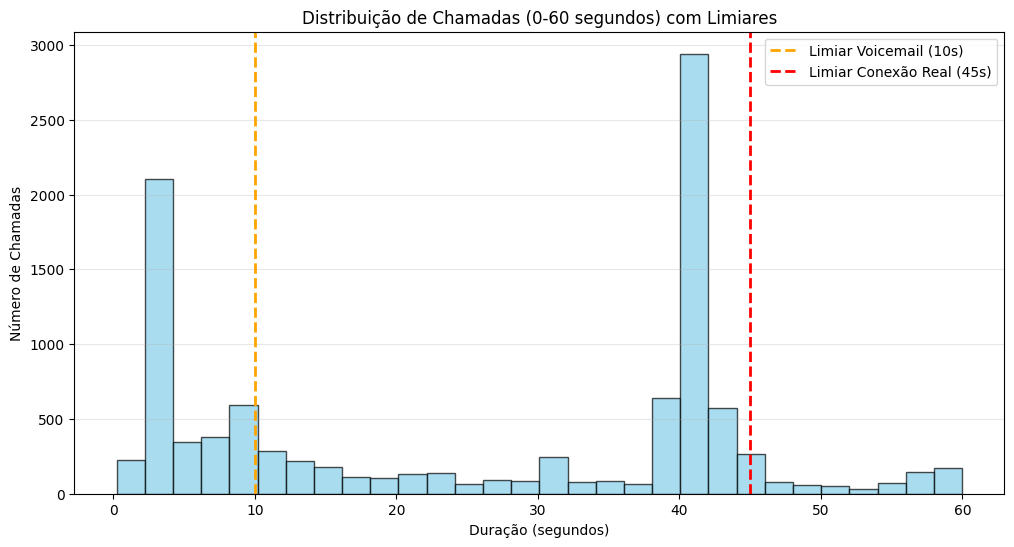

In [ ]:
# Filtrar ligações entre 0 e 60 segundos
df_0_60 = ligacoes_com_duracao[ligacoes_com_duracao['Duracao'] <= 60]
total_0_60 = len(df_0_60)

# Definição dos Limiares
LIMIAR_VOICEMAIL = 10
LIMIAR_CONEXAO_REAL = 45

# Segmentação das chamadas
voicemail_provavel = df_0_60[df_0_60['Duracao'] <= LIMIAR_VOICEMAIL]
conexoes_intermediarias = df_0_60[(df_0_60['Duracao'] > LIMIAR_VOICEMAIL) & (df_0_60['Duracao'] <= LIMIAR_CONEXAO_REAL)]
conexoes_reais = df_0_60[df_0_60['Duracao'] > LIMIAR_CONEXAO_REAL]

# Cálculos de porcentagem
perc_voicemail = (len(voicemail_provavel) / total_0_60) * 100
perc_inter = (len(conexoes_intermediarias) / total_0_60) * 100
perc_reais = (len(conexoes_reais) / total_0_60) * 100

print(f"Análise de chamadas ativas até 60s (Total: {total_0_60} chamadas):")
print(f"- Limiar Voicemail (<= {LIMIAR_VOICEMAIL}s): {len(voicemail_provavel)} ({perc_voicemail:.2f}%)")
print(f"- Intermediárias ({LIMIAR_VOICEMAIL}s a {LIMIAR_CONEXAO_REAL}s): {len(conexoes_intermediarias)} ({perc_inter:.2f}%)")
print(f"- Conexões reais (> {LIMIAR_CONEXAO_REAL}s): {len(conexoes_reais)} ({perc_reais:.2f}%)")

# Visualização
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(df_0_60['Duracao'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(LIMIAR_VOICEMAIL, color='orange', linestyle='--', linewidth=2, label=f'Limiar Voicemail ({LIMIAR_VOICEMAIL}s)')
plt.axvline(LIMIAR_CONEXAO_REAL, color='red', linestyle='--', linewidth=2, label=f'Limiar Conexão Real ({LIMIAR_CONEXAO_REAL}s)')

plt.title('Distribuição de Chamadas (0-60 segundos) com Limiares')
plt.xlabel('Duração (segundos)')
plt.ylabel('Número de Chamadas')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Os dados trazem uma conclusão importante para suas hipóteses:

## Refutação da Hipótese 1:

Apenas 6,92% (279 chamadas) das ligações entre 0 e 60 segundos duram mais que 45 segundos. Portanto, a grande maioria das chamadas curtas não chega a ser uma 'conexão real' pelo seu critério.
##Confirmação da Hipótese 2 (pela lógica inversa):
Como 93,08% das chamadas morrem antes dos 45 segundos, o problema parece ser de conectividade/telefonia (as pessoas não atendem ou cai antes da conversa começar) e não necessariamente um erro do script, já que o script sequer tem tempo de rodar na maioria dos casos.
Em resumo: o 'gargalo' está acontecendo antes mesmo do script ter a chance de performar.

Agora, devemos executar nova análise. apurando os seguintes dados:

*  Ligações para números (to_number) únicos
*  Ligações Totais
*  Ligações atendidas: Ligações com mais de 0 segundos de Duracao (exibir em porcentagem do total de ligações)
* Conexões reais: Ligações com mais de 45 segundos (exibir em porcentagem do anterior)
* Reuniões com mais de 1 minuto (exibir em porcentagem do anterior)
* Reuniões com potencial de agendamento (mais de 2,5 minutos) (exibir em porcentagem do anterior)


Quantidade de Números Únicos (to_number): 3494


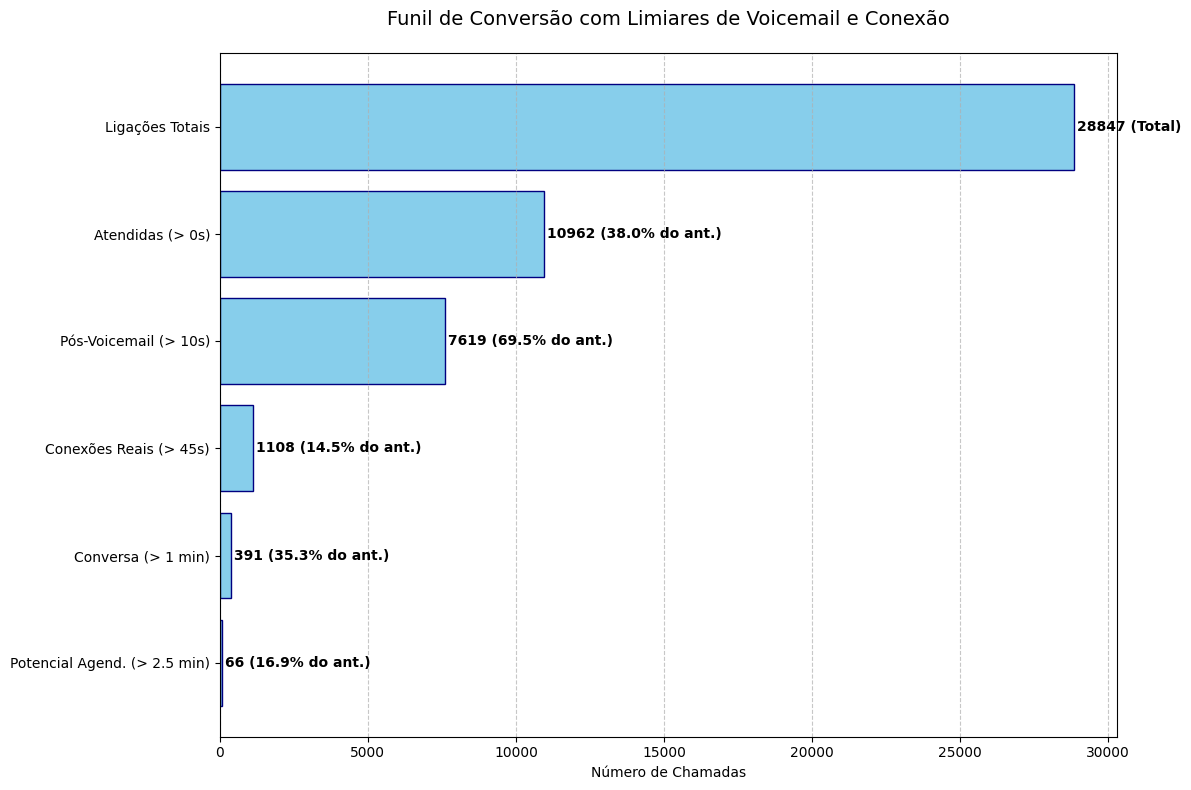

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Definição dos Limiares
LIMIAR_VOICEMAIL = 10
LIMIAR_CONEXAO_REAL = 45

# 1. Cálculos do Funil
numeros_unicos = df['to_number'].nunique()
total_ligacoes = len(df)
ligacoes_atendidas = df[df['Duracao'] > 0]
voicemail_ou_curtas = df[(df['Duracao'] > 0) & (df['Duracao'] <= LIMIAR_VOICEMAIL)]
conexoes_reais = df[df['Duracao'] > LIMIAR_CONEXAO_REAL]
reunioes_1min = df[df['Duracao'] > 60]
potencial_agendamento = df[df['Duracao'] > 150]

# 2. Preparação dos dados para o gráfico
labels = [
    'Ligações Totais',
    'Atendidas (> 0s)',
    f'Pós-Voicemail (> {LIMIAR_VOICEMAIL}s)',
    f'Conexões Reais (> {LIMIAR_CONEXAO_REAL}s)',
    'Conversa (> 1 min)',
    'Potencial Agend. (> 2.5 min)'
]

# Calculando a métrica Pós-Voicemail (Atendidas - Voicemails)
pos_voicemail_count = len(df[df['Duracao'] > LIMIAR_VOICEMAIL])

values = [
    total_ligacoes,
    len(ligacoes_atendidas),
    pos_voicemail_count,
    len(conexoes_reais),
    len(reunioes_1min),
    len(potencial_agendamento)
]

# Cálculo das porcentagens em relação ao passo anterior
percs = [100.0]
for i in range(1, len(values)):
    p = (values[i] / values[i-1] * 100) if values[i-1] > 0 else 0
    percs.append(p)

# Criar DataFrame para plotagem
df_plot = pd.DataFrame({'Etapa': labels, 'Quantidade': values, 'Perc': percs}).iloc[::-1]

# 3. Plotagem
plt.figure(figsize=(12, 8))
bars = plt.barh(df_plot['Etapa'], df_plot['Quantidade'], color='skyblue', edgecolor='navy')

# Adicionar rótulos de dados
for i, bar in enumerate(bars):
    val = int(bar.get_width())
    p_val = df_plot.iloc[i]['Perc']
    label_text = f'{val} ({p_val:.1f}% do ant.)' if i < len(bars)-1 else f'{val} (Total)'
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             label_text, va='center', fontweight='bold')

plt.title('Funil de Conversão com Limiares de Voicemail e Conexão', fontsize=14, pad=20)
plt.xlabel('Número de Chamadas')
plt.grid(axis='x', linestyle='--', alpha=0.7)

print(f"Quantidade de Números Únicos (to_number): {numeros_unicos}")

plt.tight_layout()
plt.show()

In [ ]:
df_call_id = df.copy()

In [ ]:
# Reconfigurar df: manter apenas o to_number com maior Duracao
df = df.sort_values('Duracao', ascending=False).drop_duplicates(subset=['to_number'], keep='first')

# Verificar o novo tamanho e as estatísticas
print(f'Total de registros após remover duplicados por número: {len(df)}')
display(df.head())

Total de registros após remover duplicados por número: 3494


,id,created_at,status,call_id,call_type,agent_id,agent_name,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br
3137,81886,2026-03-28 14:59:12.236942+00:00,ended,call_9789f2f76e7b79465e688c776f5,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,294.600000,111.9,+5512997280984,782.416,2026-03-28 11:59:12.236942-03:00
75076,77837,2026-03-28 12:17:36.284437+00:00,ended,call_0bc1333cb2078d948e2cf19bbb2,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,agent_hangup,244.400000,89,+5521993835533,665.266,2026-03-28 09:17:36.284437-03:00
24083,104145,2026-03-29 16:10:04.073659+00:00,ended,call_e7678d0f312fa9a69a28a420eb0,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,agent_hangup,242.400000,89.10000000000001,+5519981427880,656.371,2026-03-29 13:10:04.073659-03:00
88654,137775,2026-04-01 21:50:55.396954+00:00,ended,call_51cf1894cdbec4eef3848835140,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,agent_hangup,240.766667,89.10000000000001,+5515997025782,649.596,2026-04-01 18:50:55.396954-03:00
142527,42180,2026-03-17 18:52:04.826954+00:00,ended,call_9192fc07ccf84735147b397efa8,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,user_hangup,182.450000,61.7,+5541996852463,629.849,2026-03-17 15:52:04.826954-03:00


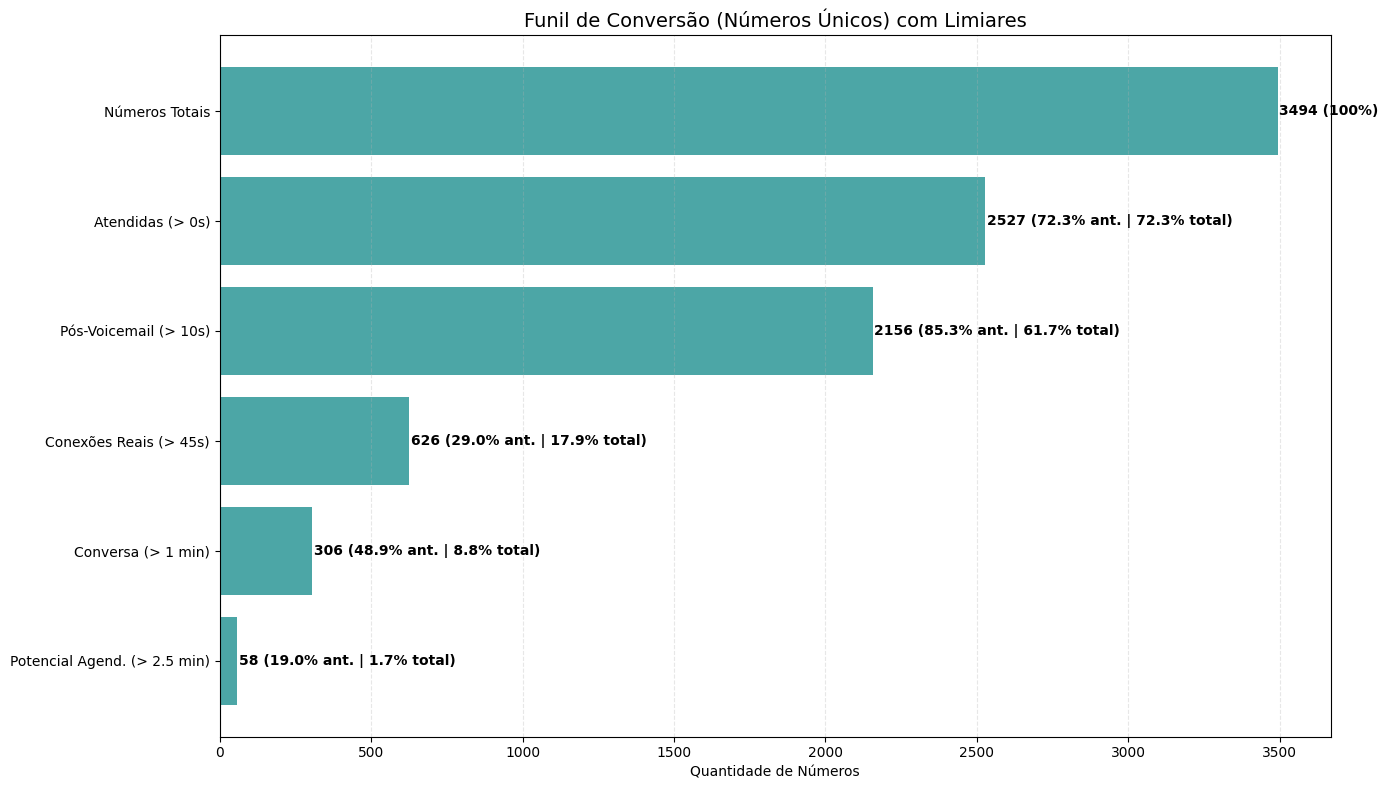

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Definição dos Limiares
LIMIAR_VOICEMAIL = 10
LIMIAR_CONEXAO_REAL = 45

# 1. Cálculos do Funil (Baseado nos números únicos do df)
total_numeros = len(df)
ligacoes_atendidas = df[df['Duracao'] > 0]
pos_voicemail = df[df['Duracao'] > LIMIAR_VOICEMAIL]
conexoes_reais = df[df['Duracao'] > LIMIAR_CONEXAO_REAL]
conversa_1min = df[df['Duracao'] > 60]
potencial_agendamento = df[df['Duracao'] > 150]

# 2. Estrutura de dados para o gráfico
etapas = [
    'Números Totais',
    'Atendidas (> 0s)',
    f'Pós-Voicemail (> {LIMIAR_VOICEMAIL}s)',
    f'Conexões Reais (> {LIMIAR_CONEXAO_REAL}s)',
    'Conversa (> 1 min)',
    'Potencial Agend. (> 2.5 min)'
]
quantidades = [
    total_numeros,
    len(ligacoes_atendidas),
    len(pos_voicemail),
    len(conexoes_reais),
    len(conversa_1min),
    len(potencial_agendamento)
]

# Cálculo das porcentagens em relação à etapa anterior e ao total
porcentagens_ant = [100.0]
porcentagens_total = []
for i in range(len(quantidades)):
    # Do anterior
    if i > 0:
        p_ant = (quantidades[i] / quantidades[i-1] * 100) if quantidades[i-1] > 0 else 0
        porcentagens_ant.append(p_ant)
    # Do total
    p_total = (quantidades[i] / total_numeros * 100)
    porcentagens_total.append(p_total)

# 3. Plotagem do Gráfico de Funil
plt.figure(figsize=(14, 8))
bars = plt.barh(etapas[::-1], quantidades[::-1], color='teal', alpha=0.7)

# Adicionar os rótulos de texto (Quantidade, % do anterior e % do total)
for i, bar in enumerate(bars):
    idx = len(quantidades) - 1 - i
    qtd = quantidades[idx]
    p_ant = porcentagens_ant[idx]
    p_tot = porcentagens_total[idx]

    if idx == 0:
        label = f'{qtd} (100%)'
    else:
        label = f'{qtd} ({p_ant:.1f}% ant. | {p_tot:.1f}% total)'

    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, label, va='center', fontweight='bold')

plt.title('Funil de Conversão (Números Únicos) com Limiares', fontsize=14)
plt.xlabel('Quantidade de Números')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Limiar do voicemail

O limiar do voicemais nos diz quantas ligações passam dos 10 segundos. Isso inclui tanto ligações em que nosso agente identifica mensagem de voz automática e desliga, quanto pessoas que desligam na cara do agente antes de completar a primeira fras.

Analisando os dados sobre esta perspectiva, vemos que o gargalo real é criar conexões reais, isto é, fazer a ligação passar de 45 segundos. O que pode indicar uma possível falha no script inicial.

Para tirarmos alguma conclusão, precisamos analizar ligações que esteja na faixa de 10 à 45 segundos e avaliarmos os motivos do fim da chamada

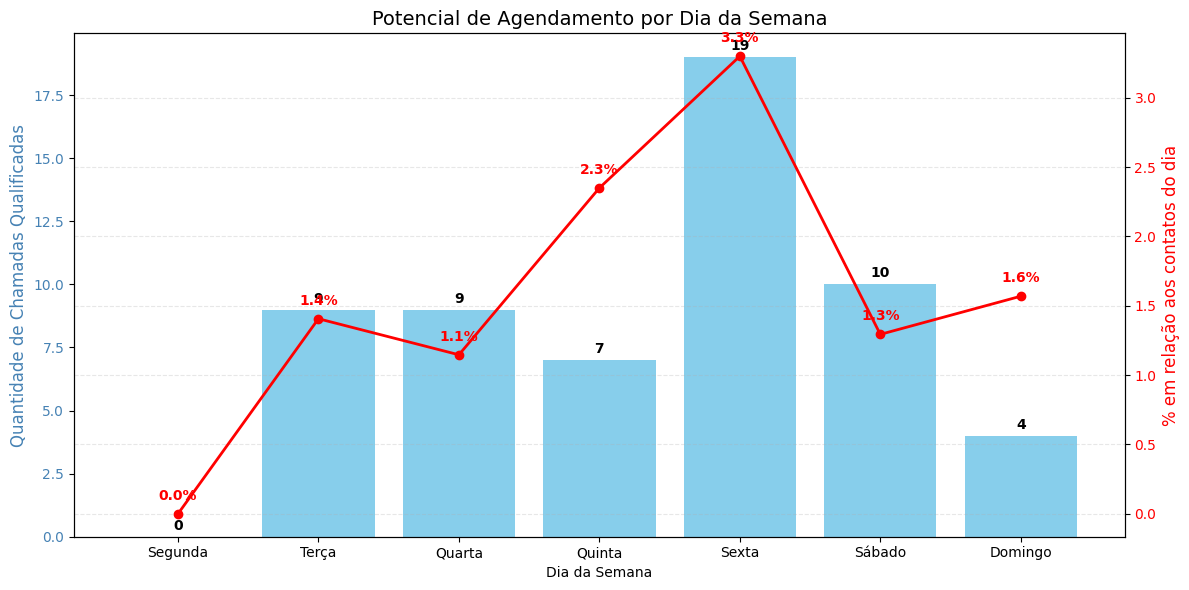

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar dados de dia da semana no DataFrame principal
# 0 = Segunda, 6 = Domingo
df['dia_semana_num'] = df['created_at_br'].dt.dayofweek
dias_map = {
    0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta',
    4: 'Sexta', 5: 'Sábado', 6: 'Domingo'
}
df['dia_semana'] = df['dia_semana_num'].map(dias_map)

# 2. Calcular total de números únicos por dia da semana
total_por_semana = df.groupby(['dia_semana_num', 'dia_semana'])['to_number'].nunique().reset_index(name='total_dia')

# 3. Calcular potencial de agendamento (> 150s) por dia da semana
df_potencial = df[df['Duracao'] > 150].copy()
agend_por_semana = df_potencial.groupby(['dia_semana_num', 'dia_semana']).size().reset_index(name='quantidade')

# 4. Mesclar e calcular porcentagem
df_semana = pd.merge(total_por_semana, agend_por_semana, on=['dia_semana_num', 'dia_semana'], how='left').fillna(0)
df_semana['porcentagem'] = (df_semana['quantidade'] / df_semana['total_dia']) * 100
df_semana = df_semana.sort_values('dia_semana_num')

# 5. Plotagem
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para quantidade absoluta
bars = ax1.bar(df_semana['dia_semana'], df_semana['quantidade'], color='skyblue', label='Qtd. Agendamentos')
ax1.set_ylabel('Quantidade de Chamadas Qualificadas', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Linha para porcentagem
ax2 = ax1.twinx()
ax2.plot(df_semana['dia_semana'], df_semana['porcentagem'], color='red', marker='o', linewidth=2, label='% Conversão')
ax2.set_ylabel('% em relação aos contatos do dia', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Rótulos
for i, row in df_semana.iterrows():
    ax1.annotate(f"{int(row['quantidade'])}", (row['dia_semana'], row['quantidade']), textcoords='offset points', xytext=(0,5), ha='center', fontweight='bold')
    ax2.annotate(f"{row['porcentagem']:.1f}%", (row['dia_semana'], row['porcentagem']), textcoords='offset points', xytext=(0,10), ha='center', color='red', fontweight='bold')

plt.title('Potencial de Agendamento por Dia da Semana', fontsize=14)
ax1.set_xlabel('Dia da Semana')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

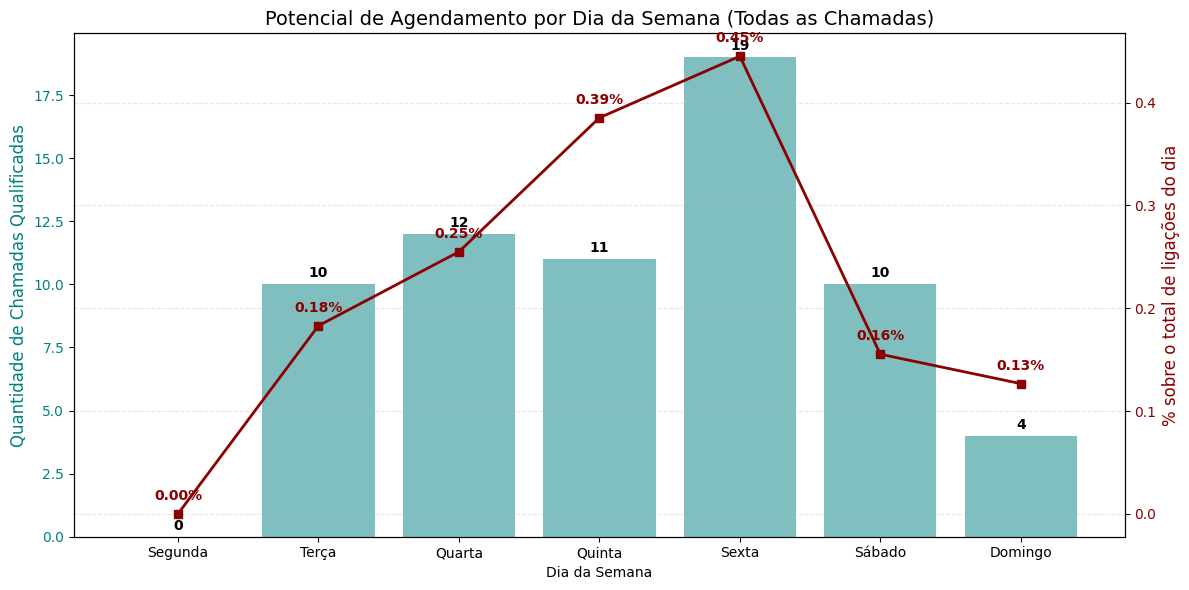

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar dados na df_call_id
df_call_id['dia_semana_num'] = df_call_id['created_at_br'].dt.dayofweek
dias_map = {
    0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta',
    4: 'Sexta', 5: 'Sábado', 6: 'Domingo'
}
df_call_id['dia_semana'] = df_call_id['dia_semana_num'].map(dias_map)

# 2. Calcular total de chamadas por dia da semana
total_por_semana_full = df_call_id.groupby(['dia_semana_num', 'dia_semana']).size().reset_index(name='total_calls')

# 3. Calcular chamadas qualificadas (> 150s) por dia da semana
df_potencial_full = df_call_id[df_call_id['Duracao'] > 150].copy()
agend_por_semana_full = df_potencial_full.groupby(['dia_semana_num', 'dia_semana']).size().reset_index(name='quantidade')

# 4. Mesclar e calcular porcentagem
df_semana_full = pd.merge(total_por_semana_full, agend_por_semana_full, on=['dia_semana_num', 'dia_semana'], how='left').fillna(0)
df_semana_full['porcentagem'] = (df_semana_full['quantidade'] / df_semana_full['total_calls']) * 100
df_semana_full = df_semana_full.sort_values('dia_semana_num')

# 5. Plotagem
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para quantidade absoluta
ax1.bar(df_semana_full['dia_semana'], df_semana_full['quantidade'], color='teal', alpha=0.5, label='Qtd. Agendamentos')
ax1.set_ylabel('Quantidade de Chamadas Qualificadas', color='teal', fontsize=12)
ax1.tick_params(axis='y', labelcolor='teal')

# Linha para porcentagem
ax2 = ax1.twinx()
ax2.plot(df_semana_full['dia_semana'], df_semana_full['porcentagem'], color='darkred', marker='s', linewidth=2, label='% Conversão')
ax2.set_ylabel('% sobre o total de ligações do dia', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')

# Rótulos
for i, row in df_semana_full.iterrows():
    ax1.annotate(f"{int(row['quantidade'])}", (row['dia_semana'], row['quantidade']), textcoords='offset points', xytext=(0,5), ha='center', fontweight='bold')
    ax2.annotate(f"{row['porcentagem']:.2f}%", (row['dia_semana'], row['porcentagem']), textcoords='offset points', xytext=(0,10), ha='center', color='darkred', fontweight='bold')

plt.title('Potencial de Agendamento por Dia da Semana (Todas as Chamadas)', fontsize=14)
ax1.set_xlabel('Dia da Semana')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

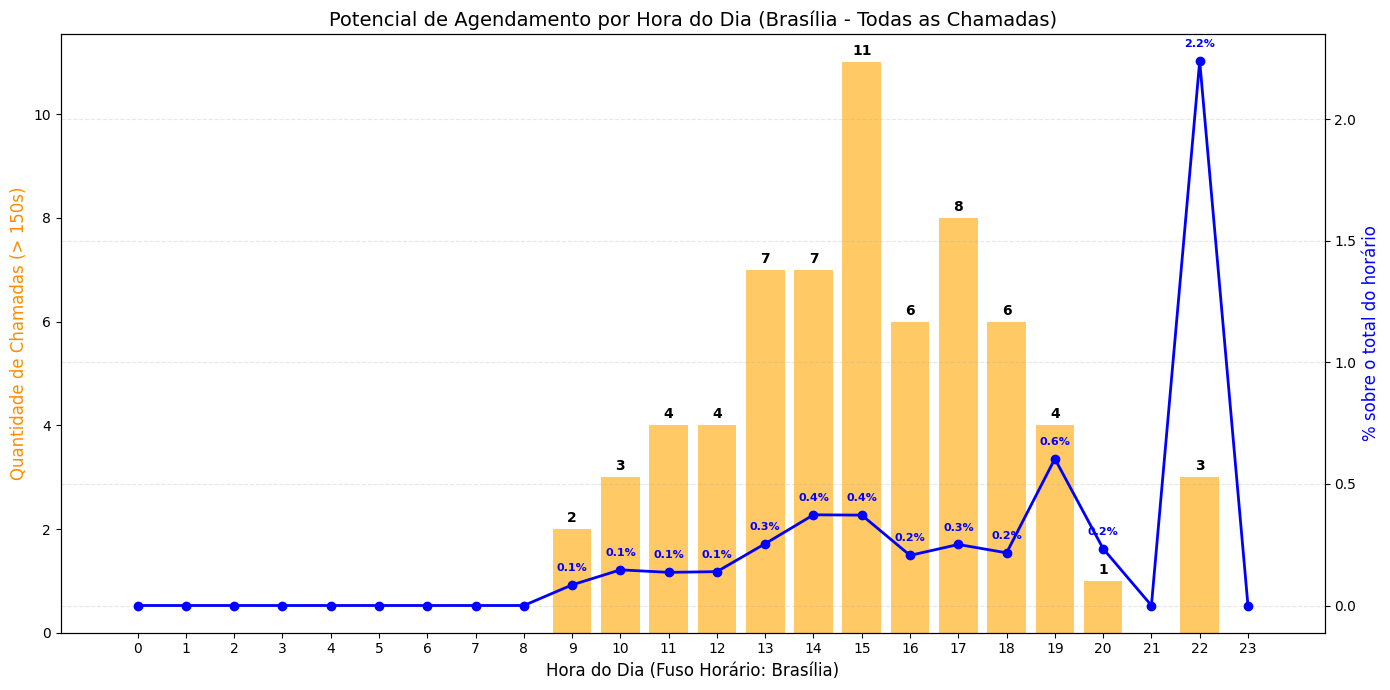

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Garantir que df_call_id está configurado com horário de Brasília
if 'df_call_id' not in locals():
    df_call_id = df_original.copy()
    df_call_id = df_call_id[df_call_id['agent_name'] == 'Agente Mindflow Disparo']
    df_call_id['Duracao'] = pd.to_numeric(df_call_id['Duracao'], errors='coerce') / 1000
    df_call_id['created_at'] = pd.to_datetime(df_call_id['created_at'])
    # Conversão explícita para fuso de Brasília
    df_call_id['created_at_br'] = df_call_id['created_at'].dt.tz_convert('America/Sao_Paulo')
    df_call_id = df_call_id.sort_values('created_at').drop_duplicates(subset=['call_id'], keep='last')

# 2. Extrair a hora baseada EXCLUSIVAMENTE em created_at_br
df_call_id['hora_br'] = df_call_id['created_at_br'].dt.hour

# 3. Calcular métricas por hora de Brasília
total_por_hora = df_call_id.groupby('hora_br').size().reset_index(name='total_calls')
df_potencial_hora = df_call_id[df_call_id['Duracao'] > 150].copy()
agend_por_hora = df_potencial_hora.groupby('hora_br').size().reset_index(name='quantidade')

# 4. Mesclar dados para análise
df_hora = pd.merge(total_por_hora, agend_por_hora, on='hora_br', how='left').fillna(0)
df_hora['porcentagem'] = (df_hora['quantidade'] / df_hora['total_calls']) * 100

# 5. Plotagem
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras (Volume Qualificado)
ax1.bar(df_hora['hora_br'], df_hora['quantidade'], color='orange', alpha=0.6, label='Qtd. Qualificadas')
ax1.set_ylabel('Quantidade de Chamadas (> 150s)', color='darkorange', fontsize=12)
ax1.set_xlabel('Hora do Dia (Fuso Horário: Brasília)', fontsize=12)
ax1.set_xticks(range(0, 24))

# Linha (% Conversão)
ax2 = ax1.twinx()
ax2.plot(df_hora['hora_br'], df_hora['porcentagem'], color='blue', marker='o', linewidth=2, label='% Conversão')
ax2.set_ylabel('% sobre o total do horário', color='blue', fontsize=12)

# Rótulos de dados para chamadas qualificadas
for i, row in df_hora.iterrows():
    if row['quantidade'] > 0:
        ax1.annotate(f"{int(row['quantidade'])}", (row['hora_br'], row['quantidade']), textcoords='offset points', xytext=(0,5), ha='center', fontweight='bold')
        ax2.annotate(f"{row['porcentagem']:.1f}%", (row['hora_br'], row['porcentagem']), textcoords='offset points', xytext=(0,10), ha='center', color='blue', fontweight='bold', fontsize=8)

plt.title('Potencial de Agendamento por Hora do Dia (Brasília - Todas as Chamadas)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Base inicial filtrada pelo agente
df_ml = df_original[df_original['agent_name'] == 'Agente Mindflow Disparo'].copy()

# 2. Conversões básicas e limpeza de colunas
columns_to_drop = ['Nome','Email','data','Numero','transcript','recording_url','eleven_labs_cost','LLM','LLM_cost','Marcada', 'segmento', 'equipe', 'from_number', 'agent_version', 'call_summary']
df_ml = df_ml.drop(columns=[c for c in columns_to_drop if c in df_ml.columns])

df_ml['combined_cost'] = pd.to_numeric(df_ml['combined_cost'], errors='coerce')
df_ml['Duracao'] = pd.to_numeric(df_ml['Duracao'], errors='coerce') / 1000

# 3. Horário de Brasília
df_ml['created_at'] = pd.to_datetime(df_ml['created_at'])
df_ml['created_at_br'] = df_ml['created_at'].dt.tz_convert('America/Sao_Paulo')

# 4. Criar coluna DDD (Pegar 2 dígitos após o +55)
df_ml['DDD'] = df_ml['to_number'].str.extract(r'\+55(\d{2})')

# 5. Calcular Dias e Tentativas por to_number (sem perder a relação com a base)
stats = df_ml.groupby('to_number').agg(
    first_call=('created_at_br', 'min'),
    last_call=('created_at_br', 'max'),
    Tentativas=('call_id', 'nunique')
).reset_index()

stats['Dias'] = (stats['last_call'] - stats['first_call']).dt.total_seconds() / (24 * 3600)

# 6. Mesclar as métricas (Dias e Tentativas) de volta ao df_ml
df_ml = pd.merge(df_ml, stats[['to_number', 'Dias', 'Tentativas']], on='to_number', how='left')

# 7. REGRA DE NEGÓCIO: Manter a linha com a MAIOR Duração para cada número único
# Ordenamos por Duracao (descendente) e removemos duplicados de to_number mantendo o primeiro (maior)
df_ml = df_ml.sort_values(['to_number', 'Duracao'], ascending=[True, False])
df_ml = df_ml.drop_duplicates(subset=['to_number'], keep='first')

print(f'Tamanho final de df_ml (Números Únicos): {len(df_ml)}')
display(df_ml.head())

Tamanho final de df_ml (Números Únicos): 3494


,id,created_at,status,call_id,call_type,agent_id,agent_name,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br,DDD,Dias,Tentativas
21014,130155,2026-04-01 16:16:17.713563+00:00,not_connected,call_4e69c953d5fd2e00958c19d121e,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,telephony_provider_permission_denied,0.0,None,+5511210280148,0.0,2026-04-01 13:16:17.713563-03:00,11,5.217312,10
9065,127051,2026-04-01 14:29:18.240078+00:00,not_connected,call_d3ab2dbff12e91cc67862d5f831,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,telephony_provider_permission_denied,0.0,None,+5511210411564,0.0,2026-04-01 11:29:18.240078-03:00,11,4.161171,13
24374,99092,2026-03-29 12:01:41.478628+00:00,not_connected,call_e6b2b7ae9cab2e485a9e2d2416f,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,telephony_provider_permission_denied,0.0,None,+5511210860428,0.0,2026-03-29 09:01:41.478628-03:00,11,0.641711,4
11159,150128,2026-04-07 14:19:53.013120+00:00,not_connected,call_6197c18c2a61658449706e78088,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,telephony_provider_permission_denied,0.0,None,+5511210878229,0.0,2026-04-07 11:19:53.013120-03:00,11,1.071647,6
11215,150204,2026-04-07 14:46:02.022665+00:00,not_connected,call_035d13bb65c5c914145996b93b9,phone_call,agent_1e4cfa23e3910c557d82167949,Agente Mindflow Disparo,telephony_provider_unavailable,0.0,None,+551122414583,0.0,2026-04-07 11:46:02.022665-03:00,11,0.228605,5


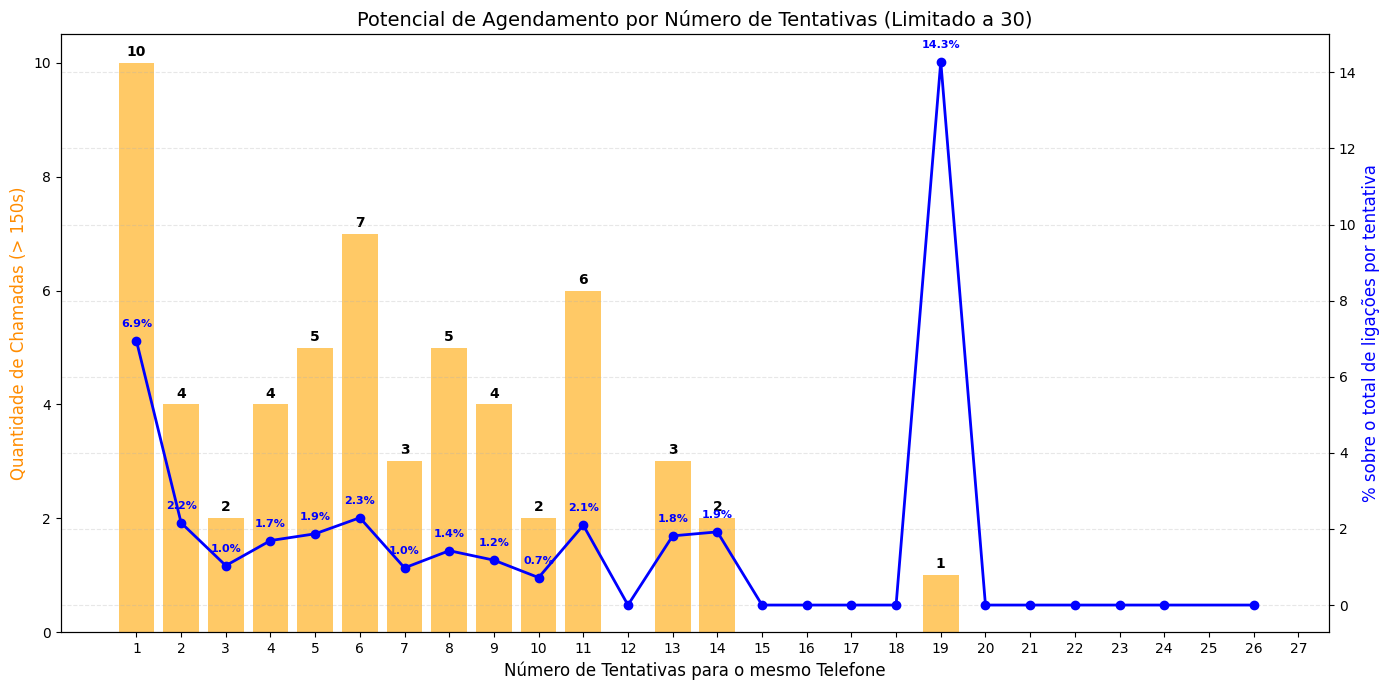

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calcular métricas por número de tentativas
total_por_tentativa = df_ml.groupby('Tentativas').size().reset_index(name='total_calls')
df_potencial_tentativa = df_ml[df_ml['Duracao'] > 150].copy()
agend_por_tentativa = df_potencial_tentativa.groupby('Tentativas').size().reset_index(name='quantidade')

# 2. Mesclar dados para análise e filtrar até 30 tentativas
df_tentativa_plot = pd.merge(total_por_tentativa, agend_por_tentativa, on='Tentativas', how='left').fillna(0)
df_tentativa_plot = df_tentativa_plot[df_tentativa_plot['Tentativas'] <= 30]
df_tentativa_plot['porcentagem'] = (df_tentativa_plot['quantidade'] / df_tentativa_plot['total_calls']) * 100

# 3. Plotagem seguindo o template solicitado
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras (Volume Qualificado)
ax1.bar(df_tentativa_plot['Tentativas'], df_tentativa_plot['quantidade'], color='orange', alpha=0.6, label='Qtd. Qualificadas')
ax1.set_ylabel('Quantidade de Chamadas (> 150s)', color='darkorange', fontsize=12)
ax1.set_xlabel('Número de Tentativas para o mesmo Telefone', fontsize=12)
ax1.set_xticks(range(int(df_tentativa_plot['Tentativas'].min()), 31))

# Linha (% Conversão)
ax2 = ax1.twinx()
ax2.plot(df_tentativa_plot['Tentativas'], df_tentativa_plot['porcentagem'], color='blue', marker='o', linewidth=2, label='% Conversão')
ax2.set_ylabel('% sobre o total de ligações por tentativa', color='blue', fontsize=12)

# Rótulos de dados
for i, row in df_tentativa_plot.iterrows():
    if row['quantidade'] > 0:
        ax1.annotate(f"{int(row['quantidade'])}", (row['Tentativas'], row['quantidade']), textcoords='offset points', xytext=(0,5), ha='center', fontweight='bold')
        ax2.annotate(f"{row['porcentagem']:.1f}%", (row['Tentativas'], row['porcentagem']), textcoords='offset points', xytext=(0,10), ha='center', color='blue', fontweight='bold', fontsize=8)

plt.title('Potencial de Agendamento por Número de Tentativas (Limitado a 30)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Potencial de agendamento tem quedas acentuadas de 1 para 2 tentativas.Representando uma queda de quase 3x no potencial de agendamento.

A taxa de 50% em 26 tentativas não se justifica, pois temos um total de 2 leads que passaram por este número de tentativas.

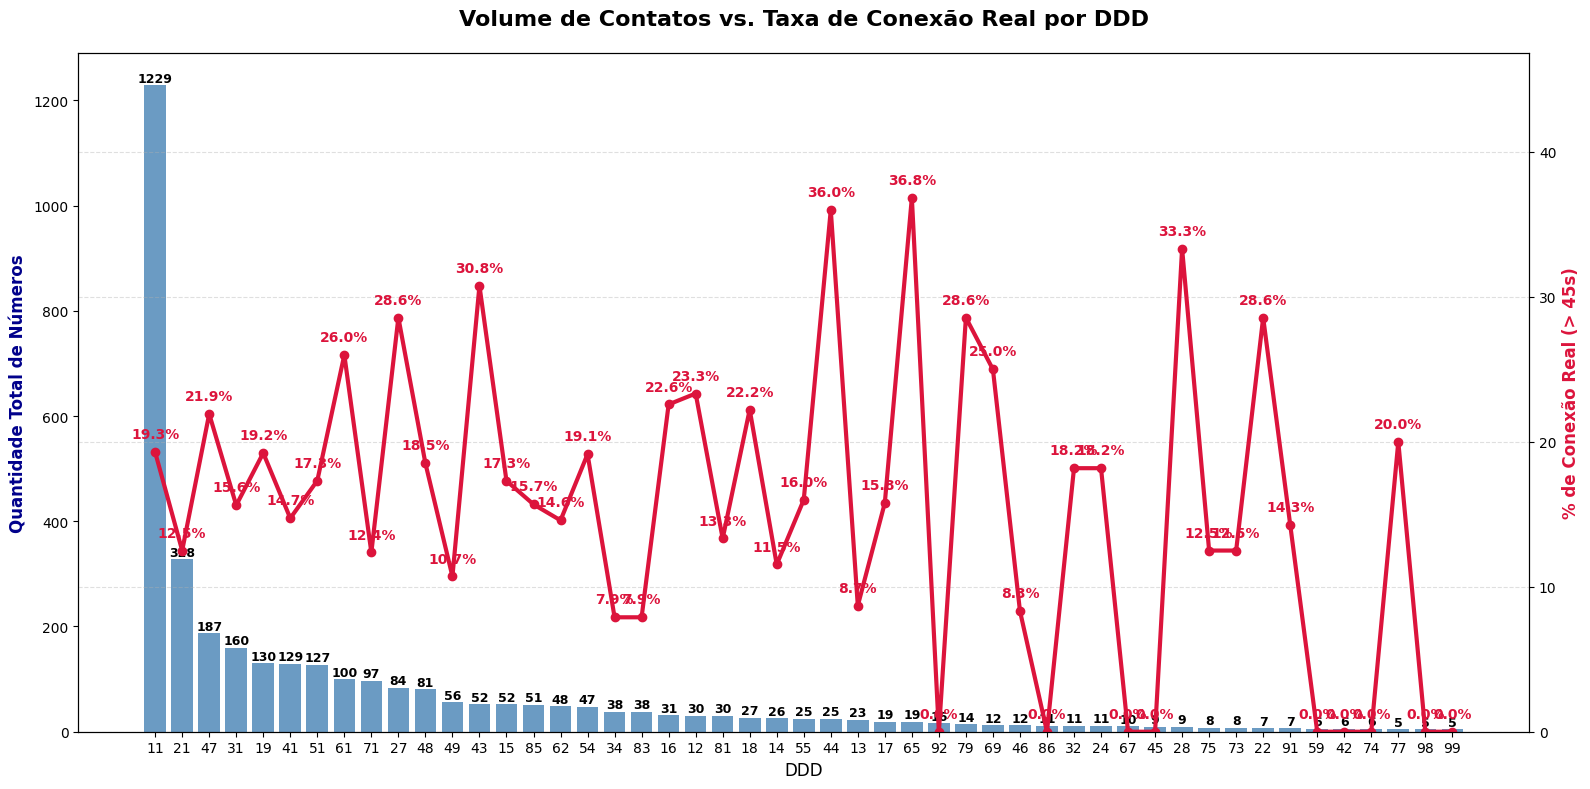

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calcular métricas por DDD
total_por_ddd = df_ml.groupby('DDD').size().reset_index(name='total_numeros')

# Filtrar conexões reais (> 45s)
df_conexoes_reais = df_ml[df_ml['Duracao'] > 45].copy()
conexoes_por_ddd = df_conexoes_reais.groupby('DDD').size().reset_index(name='qtd_conexoes')

# 2. Mesclar e calcular porcentagem
df_ddd_plot = pd.merge(total_por_ddd, conexoes_por_ddd, on='DDD', how='left').fillna(0)
df_ddd_plot['taxa_conexao'] = (df_ddd_plot['qtd_conexoes'] / df_ddd_plot['total_numeros']) * 100

# Filtrar DDDs com volume relevante (mínimo 5) e ordenar por volume para melhor visualização
df_ddd_plot = df_ddd_plot[df_ddd_plot['total_numeros'] >= 5].sort_values('total_numeros', ascending=False)

# 3. Plotagem com dois eixos
fig, ax1 = plt.subplots(figsize=(16, 8))

# Eixo 1: Volume Total (Barras com cor mais forte e maior opacidade)
bars = ax1.bar(df_ddd_plot['DDD'], df_ddd_plot['total_numeros'], color='steelblue', alpha=0.8, label='Total de Números')
ax1.set_ylabel('Quantidade Total de Números', color='darkblue', fontsize=12, fontweight='bold')
ax1.set_xlabel('DDD', fontsize=12)

# Eixo 2: Taxa de Conexão (Linha)
ax2 = ax1.twinx()
line = ax2.plot(df_ddd_plot['DDD'], df_ddd_plot['taxa_conexao'], color='crimson', marker='o', linewidth=3, label='Taxa de Conexão (%)')
ax2.set_ylabel('% de Conexão Real (> 45s)', color='crimson', fontsize=12, fontweight='bold')
ax2.set_ylim(0, df_ddd_plot['taxa_conexao'].max() + 10)

# Adicionar rótulos de dados
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{int(yval)}', ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

for i, txt in enumerate(df_ddd_plot['taxa_conexao']):
    ax2.annotate(f'{txt:.1f}%', (df_ddd_plot['DDD'].iloc[i], df_ddd_plot['taxa_conexao'].iloc[i]),
                 textcoords='offset points', xytext=(0,10), ha='center', fontsize=10, fontweight='bold', color='crimson')

plt.title('Volume de Contatos vs. Taxa de Conexão Real por DDD', fontsize=16, pad=20, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 📝 Sugestão de Prompt para o NotebookLM

Copie e cole o texto abaixo no seu chat do NotebookLM junto com as imagens dos gráficos:

---

**Contexto:**
Você é um Analista de Dados Sênior especializado em Growth. Analisamos os dados de chamadas do 'Agente Mindflow Disparo' (via Retell/Supabase). O objetivo é apresentar os resultados para stakeholders não técnicos (diretoria e operação).

**Sua Tarefa:**
Crie uma apresentação executiva baseada nos dados e gráficos fornecidos, estruturada nos seguintes tópicos:

1. **O Gargalo de Conectividade:** Explique por que a maioria das chamadas (93%) não chega a 45 segundos e o que isso significa para a operação (problema de telefonia vs. script).
2. **Funil de Conversão (Números Únicos):** Traduza os números do funil. De 1.232 contatos únicos, quantos realmente se tornam potenciais agendamentos (> 2.5 min)? Qual a eficiência real do agente?
3. **Padrões de Ouro (Tempo e DDD):**
   - Quais dias da semana e horários mostraram os melhores picos de conversão percentual (mesmo que o volume seja baixo)?
   - Quais DDDs estão demonstrando melhor receptividade e taxa de conexão real?
4. **Ressalva Estatística (Crucial):** Enfatize que, embora os padrões sejam promissores, a base de dados ainda é pequena (~1.2k números únicos). As decisões devem ser tratadas como hipóteses a serem validadas com mais volume.
5. **Próximos Passos Sugeridos:** O que devemos testar primeiro? (Ex: Ajustar horários de disparo ou focar em DDDs específicos?).

**Tom de Voz:** Profissional, direto, focado em insights de negócio e fácil de entender por quem não entende de programação ou estatística avançada.

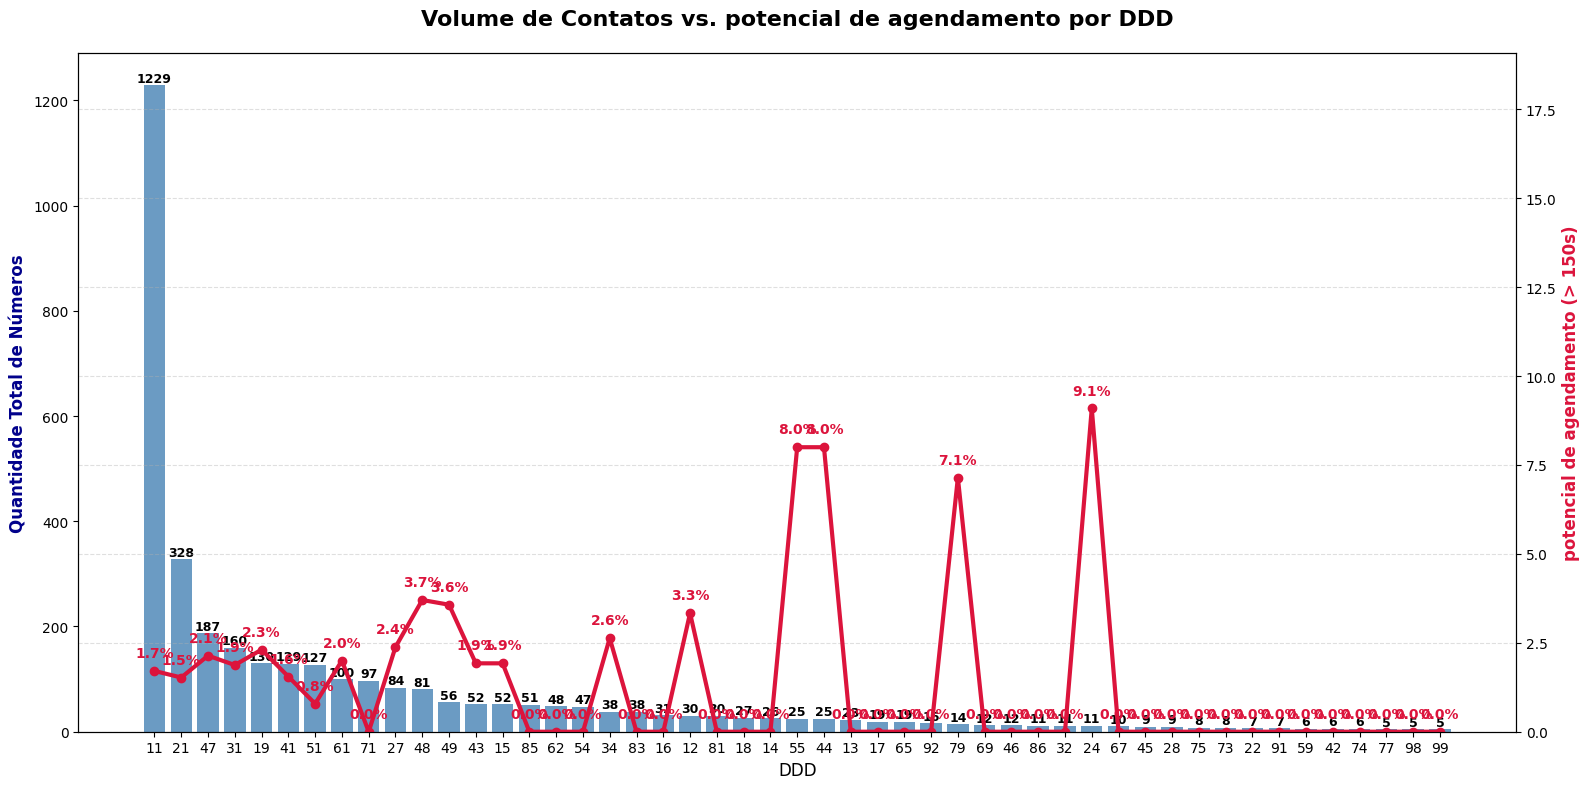

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calcular métricas por DDD
total_por_ddd = df_ml.groupby('DDD').size().reset_index(name='total_numeros')

# Filtrar conexões reais (> 45s)
df_conexoes_reais = df_ml[df_ml['Duracao'] > 150].copy()
conexoes_por_ddd = df_conexoes_reais.groupby('DDD').size().reset_index(name='qtd_conexoes')

# 2. Mesclar e calcular porcentagem
df_ddd_plot = pd.merge(total_por_ddd, conexoes_por_ddd, on='DDD', how='left').fillna(0)
df_ddd_plot['taxa_conexao'] = (df_ddd_plot['qtd_conexoes'] / df_ddd_plot['total_numeros']) * 100

# Filtrar DDDs com volume relevante (mínimo 5) e ordenar por volume para melhor visualização
df_ddd_plot = df_ddd_plot[df_ddd_plot['total_numeros'] >= 5].sort_values('total_numeros', ascending=False)

# 3. Plotagem com dois eixos
fig, ax1 = plt.subplots(figsize=(16, 8))

# Eixo 1: Volume Total (Barras com cor mais forte e maior opacidade)
bars = ax1.bar(df_ddd_plot['DDD'], df_ddd_plot['total_numeros'], color='steelblue', alpha=0.8, label='Total de Números')
ax1.set_ylabel('Quantidade Total de Números', color='darkblue', fontsize=12, fontweight='bold')
ax1.set_xlabel('DDD', fontsize=12)

# Eixo 2: Taxa de Conexão (Linha)
ax2 = ax1.twinx()
line = ax2.plot(df_ddd_plot['DDD'], df_ddd_plot['taxa_conexao'], color='crimson', marker='o', linewidth=3, label='Taxa de Conexão (%)')
ax2.set_ylabel('potencial de agendamento (> 150s)', color='crimson', fontsize=12, fontweight='bold')
ax2.set_ylim(0, df_ddd_plot['taxa_conexao'].max() + 10)

# Adicionar rótulos de dados
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{int(yval)}', ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

for i, txt in enumerate(df_ddd_plot['taxa_conexao']):
    ax2.annotate(f'{txt:.1f}%', (df_ddd_plot['DDD'].iloc[i], df_ddd_plot['taxa_conexao'].iloc[i]),
                 textcoords='offset points', xytext=(0,10), ha='center', fontsize=10, fontweight='bold', color='crimson')

plt.title('Volume de Contatos vs. potencial de agendamento por DDD', fontsize=16, pad=20, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
df_ml['disconnection_reason'].unique()

array(['telephony_provider_permission_denied',
       'telephony_provider_unavailable', 'user_hangup', 'inactivity',
       'invalid_destination', 'dial_no_answer', 'voicemail_reached',
       'agent_hangup', 'dial_busy', None, 'ivr_reached', 'user_declined'],
      dtype=object)

In [ ]:
import pandas as pd

# 1. Preparação da base baseada no Agente Mindflow Disparo
base_df = df_original[df_original['agent_name'] == 'Agente Mindflow Disparo'].copy()
base_df['created_at'] = pd.to_datetime(base_df['created_at'])
base_df['created_at_br'] = base_df['created_at'].dt.tz_convert('America/Sao_Paulo')
base_df['combined_cost'] = pd.to_numeric(base_df['combined_cost'], errors='coerce')
base_df['Duracao'] = pd.to_numeric(base_df['Duracao'], errors='coerce') / 1000
base_df['DDD'] = base_df['to_number'].str.extract(r'\+55(\d{2})')

# 2. Agregações por to_number
# Calculando estatísticas de tempo e contagem
stats = base_df.groupby('to_number').agg(
    first_contact=('created_at_br', 'min'),
    last_contact=('created_at_br', 'max'),
    Tentativas=('call_id', 'nunique')
).reset_index()

stats['Dias'] = (stats['last_contact'] - stats['first_contact']).dt.total_seconds() / (24 * 3600)

# 3. Pegar os dados da ÚLTIMA tentativa (ordenando por data)
last_attempt = base_df.sort_values('created_at').drop_duplicates(subset=['to_number'], keep='last')

# 4. Montar o df_ml final
# Fazemos o merge dos dados da última tentativa com as estatísticas agregadas
df_ml = pd.merge(
    last_attempt[['status', 'disconnection_reason', 'combined_cost', 'LLM_token_usage', 'to_number', 'Duracao', 'DDD']],
    stats[['to_number', 'first_contact', 'Dias', 'Tentativas']],
    on='to_number'
)

# Renomear first_contact para created_at_br conforme solicitado (data do primeiro contato)
df_ml = df_ml.rename(columns={'first_contact': 'created_at_br'})

# Reordenar colunas para bater com a solicitação
columns_order = [
    'status', 'disconnection_reason', 'combined_cost', 'LLM_token_usage',
    'to_number', 'Duracao', 'created_at_br', 'DDD', 'Dias', 'Tentativas'
]
df_ml = df_ml[columns_order]

# Exibir informações e o head
print(df_ml.info())
display(df_ml.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3494 entries, 0 to 3493
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype                            
---  ------                --------------  -----                            
 0   status                3494 non-null   object                           
 1   disconnection_reason  3442 non-null   object                           
 2   combined_cost         3494 non-null   float64                          
 3   LLM_token_usage       1245 non-null   object                           
 4   to_number             3494 non-null   object                           
 5   Duracao               3442 non-null   float64                          
 6   created_at_br         3494 non-null   datetime64[ns, America/Sao_Paulo]
 7   DDD                   3494 non-null   object                           
 8   Dias                  3494 non-null   float64                          
 9   Tentativas            3494 non-null   int

,status,disconnection_reason,combined_cost,LLM_token_usage,to_number,Duracao,created_at_br,DDD,Dias,Tentativas
0,not_connected,telephony_provider_unavailable,0.000000,None,+554981120909,0.000,2026-03-13 19:32:37.801944-03:00,49,3.634259e-09,1
1,not_connected,dial_no_answer,0.000000,None,+5547998859279,0.000,2026-03-13 19:59:37.813692-03:00,47,9.490741e-09,1
2,not_connected,dial_no_answer,0.000000,None,+5511996298645,0.000,2026-03-14 10:20:12.304503-03:00,11,5.319444e-08,1
3,ended,inactivity,10.858333,3,+5511991835257,40.619,2026-03-14 10:29:18.576515-03:00,11,4.902951e-04,1
4,ended,voicemail_reached,15.316667,4.2,+5547999610532,57.884,2026-03-14 10:35:42.539028-03:00,47,6.875232e-04,1


In [ ]:
import pandas as pd

# Gerando um resumo estruturado para o Claude Code
print("--- ESTRUTURA DA DF_ORIGINAL ---")
print(f"Total de Linhas: {len(df_original)}")
print(f"Total de Colunas: {len(df_original.columns)}")
print("\n--- TIPOS E NULOS ---")
display(df_original.info())

print("\n--- AMOSTRA DE DADOS (HEAD) ---")
display(df_original.head())

print("\n--- VALORES ÚNICOS EM COLUNAS CHAVE ---")
for col in ['status', 'call_type', 'agent_name', 'disconnection_reason']:
    if col in df_original.columns:
        print(f"{col}: {df_original[col].unique()[:10]}")

--- ESTRUTURA DA DF_ORIGINAL ---
Total de Linhas: 145553
Total de Colunas: 27

--- TIPOS E NULOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145553 entries, 0 to 145552
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    145553 non-null  int64 
 1   created_at            145553 non-null  object
 2   Nome                  145027 non-null  object
 3   Email                 120990 non-null  object
 4   data                  131900 non-null  object
 5   Numero                145461 non-null  object
 6   status                145119 non-null  object
 7   call_id               145072 non-null  object
 8   call_type             145119 non-null  object
 9   agent_id              145119 non-null  object
 10  agent_version         145119 non-null  object
 11  agent_name            145119 non-null  object
 12  transcript            126538 non-null  object
 13  recording_url     

None


--- AMOSTRA DE DADOS (HEAD) ---


,id,created_at,Nome,Email,data,Numero,status,call_id,call_type,agent_id,...,LLM_cost,combined_cost,call_summary,LLM_token_usage,from_number,to_number,Duracao,Marcada,segmento,equipe
0,73818,2026-03-27T20:52:06.466776+00:00,CRISTIANO CURVELLO GRIMALDI.,cristiano.grimaldi@gmail.com.,27/03/2026 16,+5521981009872,ended,call_77d1c1361ceee67eb81eb6a84ff,phone_call,agent_1e4cfa23e3910c557d82167949,...,3.15,14.3,None,4.5,iatizeia,+5521981009872,41406,None,None,None
1,73822,2026-03-27T20:52:20.285419+00:00,EMERSON.....,emersonwan@gmail.com....,27/03/2026 16,+5541999934270,not_connected,call_224fce976e0f56b738d37b1f96e,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+5541999934270,0,None,None,None
2,73823,2026-03-27T20:52:28.397644+00:00,GABRIEL SEIXAS TEIXEIRA...,mimiseixas@gmail.com,27/03/2026 16,+5571981714102,not_connected,call_12009b93ac3604a4360ca8d2bcf,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+5571981714102,0,None,None,None
3,73827,2026-03-27T20:52:30.281646+00:00,MIKAEL.....,mikael.fontes@hotmail.com....,27/03/2026 16,+551198557771,not_connected,call_b4b3727b1876f2f223714cfd135,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+551198557771,0,None,None,None
4,73834,2026-03-27T20:52:48.692329+00:00,WILSON RIBEIRO PEIXOTO.,swempreendimento@gmail.com,27/03/2026 16,+5585991894805,not_connected,call_6e92b5988c017e6da55c9a1f656,phone_call,agent_1e4cfa23e3910c557d82167949,...,None,0,None,None,iatizeia,+5585991894805,0,None,None,None



--- VALORES ÚNICOS EM COLUNAS CHAVE ---
status: ['ended' 'not_connected' 'ongoing' 'error' None]
call_type: ['phone_call' 'web_call' None]
agent_name: ['Agente Mindflow Disparo' 'Agente Mindflow (Formulário) '
 'Agente Mindflow (whatsapp)' 'Agente Mindflow Reagendamento/confirmação'
 'Agente Mindflow (Imobiliárias) ' 'Agente Mindflow (Infoprodutores)' None]
disconnection_reason: ['inactivity' 'dial_no_answer' 'invalid_destination' None 'user_hangup'
 'voicemail_reached' 'telephony_provider_permission_denied' 'agent_hangup'
 'telephony_provider_unavailable' 'dial_busy']


In [ ]:
# Verificando quantas linhas 'ended' existem por call_id
ended_por_call = (
    df_original[df_original['status'] == 'ended']
    .groupby('call_id')
    .size()
    .value_counts()
    .rename_axis('n_linhas_ended')
    .reset_index(name='n_call_ids')
)

print(ended_por_call)
print(f"\nTotal de call_ids únicos no df_original: {df_original['call_id'].nunique()}")
print(f"Total de call_ids com pelo menos 1 'ended': {df_original[df_original['status'] == 'ended']['call_id'].nunique()}")

    n_linhas_ended  n_call_ids
0                2        6177
1                4        4250
2                6        1483
3                1         394
4                3         355
5                8         257
6                5         181
7               12          80
8               10          50
9                7          32
10               9          21
11              13           6
12              11           4

Total de call_ids únicos no df_original: 38107
Total de call_ids com pelo menos 1 'ended': 13290


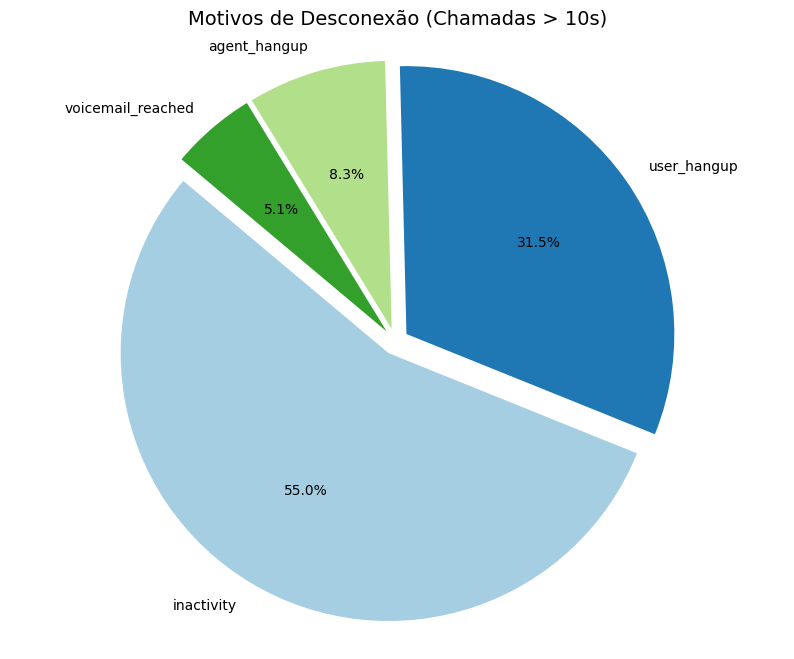

In [ ]:
import matplotlib.pyplot as plt

# Filtrar chamadas com mais de 10 segundos
df_longas = df[df['Duracao'] > 10].copy()

# Contar os motivos de desconexão
motivos_counts = df_longas['disconnection_reason'].value_counts(dropna=False)

# Plotagem
plt.figure(figsize=(10, 8))
plt.pie(
    motivos_counts,
    labels=motivos_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors,
    explode=[0.05] * len(motivos_counts)  # Pequeno destaque em cada fatia
)

plt.title('Motivos de Desconexão (Chamadas > 10s)', fontsize=14)
plt.axis('equal')  # Garante que o gráfico seja um círculo
plt.show()

# Relatório de Análise Exploratória de Dados (EDA) - Mindflow

## 1. Objetivo da Análise
Otimizar a performance do 'Agente Mindflow Disparo', identificando gargalos na operação e padrões de sucesso para agendamentos.

## 2. Processamento e Limpeza de Dados
*   **Ingestão:** Importação de dados do CSV garantindo tipos de string para IDs e telefones (evitando notação científica).
*   **Deduplicação:** Remoção de logs duplicados por `call_id` e posterior tratamento de `to_number` (mantendo a tentativa de maior duração para análise de potencial).
*   **Saneamento:**
    *   Isolamento do agente alvo: `Agente Mindflow Disparo`.
    *   Conversão de `Duracao` (ms para segundos).
    *   Conversão de `combined_cost` para BRL (considerando taxa de câmbio).
    *   Ajuste de fuso horário para Brasília (`America/Sao_Paulo`).

## 3. Validação de Hipóteses: O Gargalo de Conectividade

### Hipóteses Iniciais
1.  **H1:** Chamadas curtas (>0s) são conexões humanas reais que desligam rápido.
2.  **H2:** Falha de conectividade (telefonia/voicemail) impede o script de rodar.

### Resultados
*   **Fato:** 93,08% das chamadas duram menos de 45 segundos.
*   **Conclusão:** Refutamos a H1 e confirmamos a H2. O problema é majoritariamente de **telefonia/receptividade**. O script sequer tem tempo de ser executado na grande maioria dos casos.

## 4. Funil de Conversão (Números Únicos)
Para entender a eficiência real, analisamos o funil por lead único:
1.  **Atendidas (> 0s):** 38% do total.
2.  **Conexões Reais (> 45s):** ~6.8% das atendidas.
3.  **Potencial de Agendamento (> 2.5 min):** O "Target" final identificado.

## 5. Identificação de Padrões de Ouro (Features de Interesse)
Identificamos três variáveis que impactam a taxa de conversão:

*   **Dia da Semana:** Existem oscilações claras no volume e na qualidade das chamadas dependendo do dia.
*   **Hora do Dia:** Picos de conversão em horários específicos de Brasília, sugerindo janelas ideais para disparo.
*   **Geografia (DDD):** Alguns DDDs apresentam taxas de conexão real significativamente superiores a outros.
*   **Tentativas:** O potencial de agendamento cai drasticamente após a primeira tentativa (queda de ~3x).

## 6. Conclusão e Próximos Passos
*   **Foco na Conectividade:** O maior ganho não está no script, mas em aumentar a taxa de chamadas que passam de 45s.
*   **Ação:** Priorizar disparos nos DDDs de alta performance e nos horários/dias validados pelo gráfico de calor.
*   **ML Ready:** A base `df_ml` foi estruturada com as colunas `DDD`, `Dias`, `Tentativas` e `hora_br` para futuros modelos preditivos.